### 1. Common imports, loading and transforming required datafiles.
**Run this first for all cases.**

In [ ]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import torch
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GCNConv
import torch.nn.functional as F
from sklearn.preprocessing import MinMaxScaler

# Filepaths to pre-processed datasets
distance_path = '../data/florida_distance.csv'
load_path = '../data/florida_load.csv'

# Load the distance dataset
df_dist = pd.read_csv(distance_path)

# Calculate the bandwidth (sigma) using the median distance
sigma = df_dist['distance'].median()
print(f"Median Distance (sigma): {sigma:.2f} miles")

# Transform distance to similarity weight using the Gaussian kernel
df_dist['weight'] = np.exp(-(df_dist['distance']**2) / (sigma**2))

# Sparsify the Graph (Thresholding)
lambda_threshold = 0.2
df_sparse = df_dist[df_dist['weight'] >= lambda_threshold]

print(f"Original edges (Fully Connected): {len(df_dist)}")
print(f"Remaining edges (Sparse Graph): {len(df_sparse)}")

### 2. Examine graph using NetworkX
Draw and calculate some properties of the graph.

Median Distance (sigma): 164.18 miles
Original edges (Fully Connected): 4422
Remaining edges (Sparse Graph): 2782


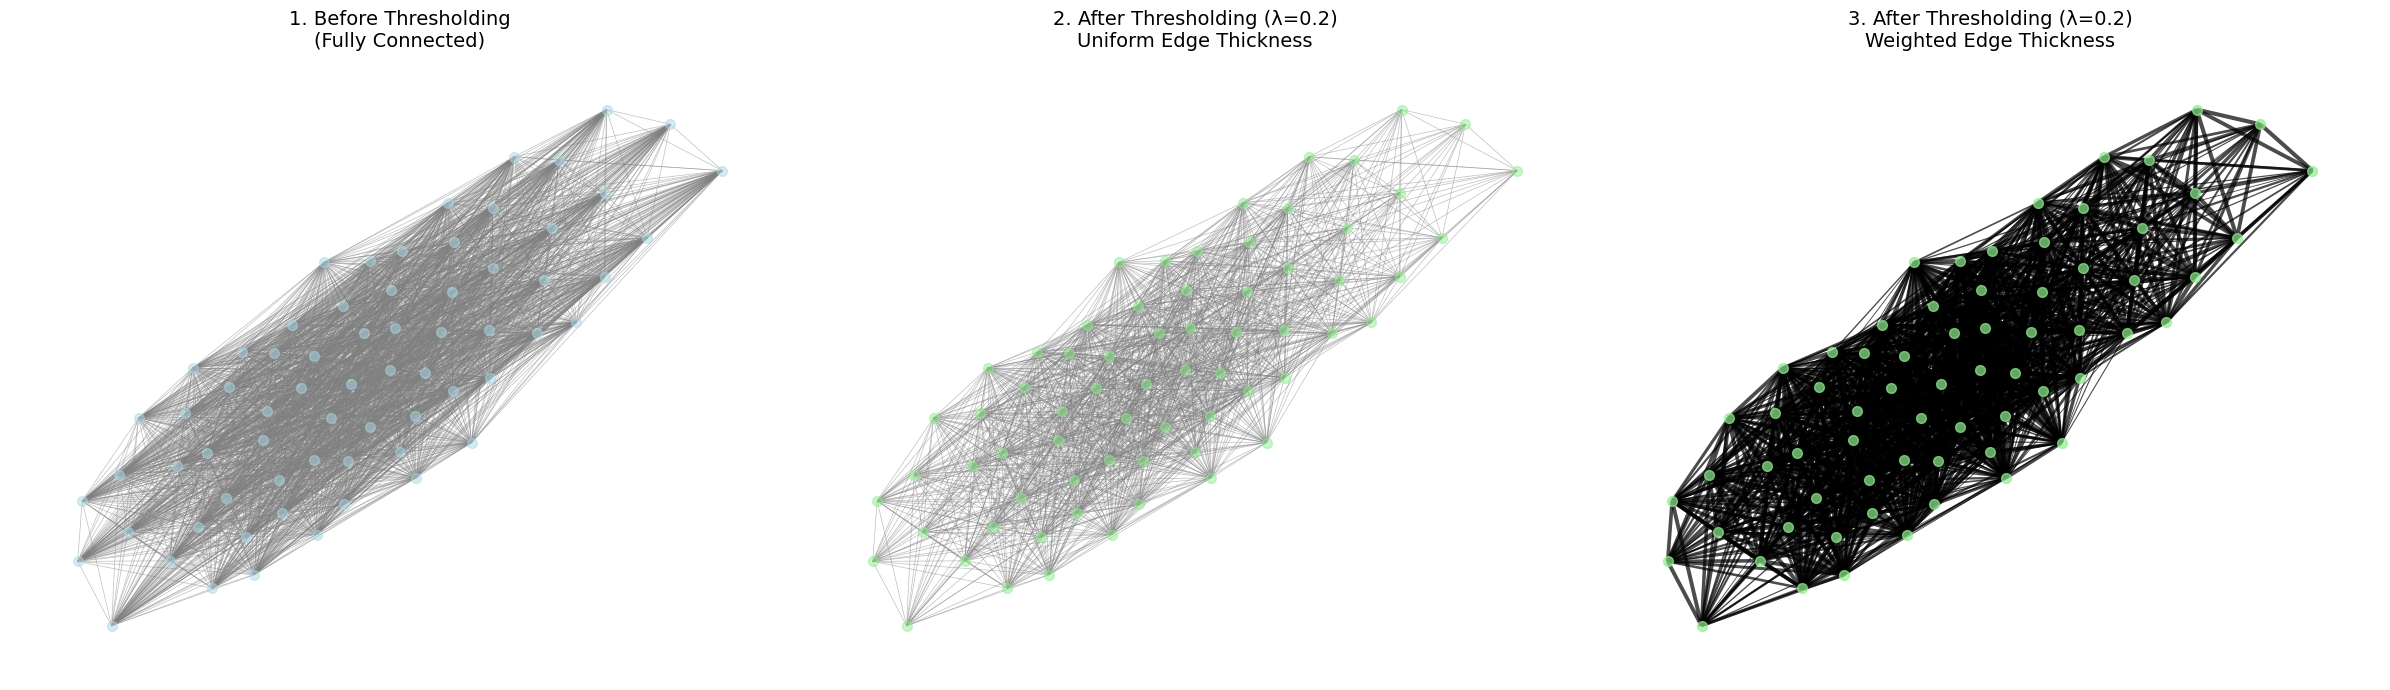

In [3]:
# Build NetworkX Graphs
G_fully_connected = nx.from_pandas_edgelist(
    df_dist, source='county1', target='county2', edge_attr=['distance', 'weight']
)
G_sparse = nx.from_pandas_edgelist(
    df_sparse, source='county1', target='county2', edge_attr=['distance', 'weight']
)
G_sparse.add_nodes_from(G_fully_connected.nodes())

# Plot the 3 Variations
pos = nx.spring_layout(G_fully_connected, seed=42)
fig, axes = plt.subplots(1, 3, figsize=(24, 7))

nx.draw(G_fully_connected, pos, ax=axes[0], node_color='lightblue', with_labels=False, edge_color='gray', width=0.5, alpha=0.5, node_size=50)
axes[0].set_title("1. Before Thresholding\n(Fully Connected)", fontsize=14)

nx.draw(G_sparse, pos, ax=axes[1], node_color='lightgreen', with_labels=False, edge_color='gray', width=0.5, alpha=0.5, node_size=50)
axes[1].set_title(f"2. After Thresholding (λ={lambda_threshold})\nUniform Edge Thickness", fontsize=14)

edges = G_sparse.edges(data=True)
weights = [edge_data[2]['weight'] * 3.0 for edge_data in edges]
nx.draw(G_sparse, pos, ax=axes[2], node_color='lightgreen', with_labels=False, edge_color='black', width=weights, alpha=0.7, node_size=50)
axes[2].set_title(f"3. After Thresholding (λ={lambda_threshold})\nWeighted Edge Thickness", fontsize=14)

plt.tight_layout()
plt.show()

### 3. PyTorch Geometric setup
**Run first for either training and/or testing.**

In [4]:
# Load the time-series load data
df_load = pd.read_csv(load_path)

# Extract node IDs (FIPS codes) from the column headers
county_fips = list(df_load.columns[1:])
num_nodes = len(county_fips)

# 1. Create a mapping from FIPS code to an integer index (0 to 66)
fips_to_idx = {int(fips): idx for idx, fips in enumerate(county_fips)}

# 2. Convert Edge List to PyG Format
# Map the source and target counties to their new integer IDs
src = df_sparse['county1'].map(fips_to_idx).values
dst = df_sparse['county2'].map(fips_to_idx).values
edge_weights = df_sparse['weight'].values

# PyG expects edge_index of shape [2, num_edges]
edge_index = torch.tensor([src, dst], dtype=torch.long)
edge_attr = torch.tensor(edge_weights, dtype=torch.float)

# 3. Process the Time-Series Data
# Extract only the numerical load values (Rows = Time, Cols = Counties)
load_values = df_load.iloc[:, 1:].values

# Neural networks require normalized data for stable training
scaler = MinMaxScaler()
load_normalized = scaler.fit_transform(load_values)

# Transpose so rows are counties (nodes) and cols are time: Shape [num_nodes, Total_Hours]
load_normalized = load_normalized.T

# Create sliding windows (Past 24 hours -> Predict Next 1 hour)
window_size = 24
dataset = []

# To keep training fast for testing, let's use a subset of the data (e.g., first 5000 hours)
# You can remove the slicing [:5000] to train on the full 2016-2023 dataset later
total_time_steps = min(5000, load_normalized.shape[1])

for t in range(total_time_steps - window_size):
    # Node features: past 'window_size' hours (Shape: [num_nodes, 24])
    x = torch.tensor(load_normalized[:, t : t + window_size], dtype=torch.float)

    # Target: the load at the very next hour (Shape: [num_nodes, 1])
    y = torch.tensor(load_normalized[:, t + window_size], dtype=torch.float).unsqueeze(1)

    # Create a PyG Data object for this specific time snapshot
    graph_snapshot = Data(x=x, edge_index=edge_index, edge_weight=edge_attr, y=y)
    dataset.append(graph_snapshot)

print(f"Created {len(dataset)} graph snapshots for training/testing.")

# Split into Train (80%) and Test (20%)
train_size = int(len(dataset) * 0.8)
train_dataset = dataset[:train_size]
test_dataset = dataset[train_size:]

# DataLoaders batch multiple graph snapshots together for faster training
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

Created 4976 graph snapshots for training/testing.


/tmp/ipykernel_66359/2780055245.py:18: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  edge_index = torch.tensor([src, dst], dtype=torch.long)


### 4. Model definition and implementation
**Run this cell before training in cell 5.**

In [5]:
class LoadForecastingGCN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super(LoadForecastingGCN, self).__init__()
        # GCN Layer 1: Aggregates neighbor information
        self.conv1 = GCNConv(in_channels, hidden_channels)
        # GCN Layer 2: Further aggregation
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        # Linear output layer to predict the exact load value
        self.linear = torch.nn.Linear(hidden_channels, out_channels)

    def forward(self, data):
        x, edge_index, edge_weight = data.x, data.edge_index, data.edge_weight

        # Message passing with spatial weights
        x = self.conv1(x, edge_index, edge_weight)
        x = F.relu(x)
        x = F.dropout(x, p=0.2, training=self.training)

        x = self.conv2(x, edge_index, edge_weight)
        x = F.relu(x)

        # Output prediction
        out = self.linear(x)
        return out

# Initialize the model
# in_channels = 24 (past 24 hours), out_channels = 1 (next hour)
model = LoadForecastingGCN(in_channels=window_size, hidden_channels=32, out_channels=1)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
criterion = torch.nn.MSELoss()

print(model)

LoadForecastingGCN(
  (conv1): GCNConv(24, 32)
  (conv2): GCNConv(32, 32)
  (linear): Linear(in_features=32, out_features=1, bias=True)
)


### 5. Training the model
You may skip training if you have an existing checkpoint.

Starting Training...
Epoch: 001, Train Loss: 0.0132, Test Loss: 0.0129
Epoch: 011, Train Loss: 0.0053, Test Loss: 0.0061
Epoch: 021, Train Loss: 0.0046, Test Loss: 0.0058
Epoch: 031, Train Loss: 0.0045, Test Loss: 0.0056
Epoch: 041, Train Loss: 0.0044, Test Loss: 0.0059
Epoch: 051, Train Loss: 0.0043, Test Loss: 0.0054
Epoch: 061, Train Loss: 0.0043, Test Loss: 0.0052
Epoch: 071, Train Loss: 0.0042, Test Loss: 0.0054
Epoch: 081, Train Loss: 0.0043, Test Loss: 0.0053
Epoch: 091, Train Loss: 0.0042, Test Loss: 0.0064
Epoch: 101, Train Loss: 0.0042, Test Loss: 0.0054
Epoch: 111, Train Loss: 0.0041, Test Loss: 0.0055
Epoch: 121, Train Loss: 0.0042, Test Loss: 0.0052
Epoch: 131, Train Loss: 0.0041, Test Loss: 0.0065
Epoch: 141, Train Loss: 0.0041, Test Loss: 0.0049
Epoch: 151, Train Loss: 0.0042, Test Loss: 0.0068
Epoch: 161, Train Loss: 0.0041, Test Loss: 0.0051
Epoch: 171, Train Loss: 0.0041, Test Loss: 0.0056
Epoch: 181, Train Loss: 0.0041, Test Loss: 0.0057
Epoch: 191, Train Loss: 0.004

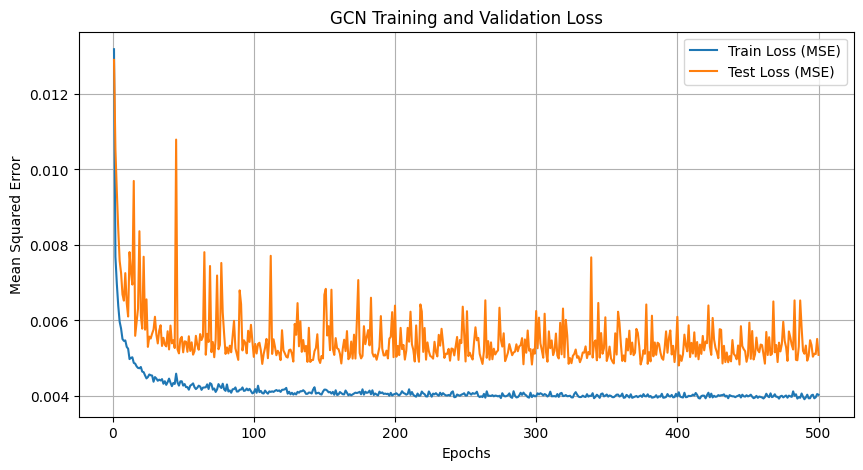

In [6]:
import copy
import matplotlib.pyplot as plt

# Use CUDA GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

def train():
    model.train()
    total_loss = 0
    for batch in train_loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        out = model(batch)
        loss = criterion(out, batch.y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * batch.num_graphs
    return total_loss / len(train_dataset)

def validate():
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for batch in test_loader:
            batch = batch.to(device)
            out = model(batch)
            loss = criterion(out, batch.y)
            total_loss += loss.item() * batch.num_graphs
    return total_loss / len(test_dataset)

# Tracking variables
train_losses = []
test_losses = []
best_loss = float('inf')
best_model_state = None

epochs = 500 # Increased epochs for better learning

print("Starting Training...")
for epoch in range(epochs):
    train_loss = train()
    test_loss = validate()

    train_losses.append(train_loss)
    test_losses.append(test_loss)

    # Save the model if it's the best we've seen so far
    if test_loss < best_loss:
        best_loss = test_loss
        best_model_state = copy.deepcopy(model.state_dict())
        torch.save(best_model_state, 'best_load_forecasting_gcn.pth')

    # Print statistics every few epochs
    if epoch == 0 or epoch % 10 == 9:
        print(f'Epoch: {epoch+1:03d}, Train Loss: {train_loss:.4f}, Test Loss: {test_loss:.4f}')

print("Training Complete! Best model saved as 'best_load_forecasting_gcn.pth'")

# --- Plot the Learning Curve ---
plt.figure(figsize=(10, 5))
plt.plot(range(1, epochs + 1), train_losses, label='Train Loss (MSE)')
plt.plot(range(1, epochs + 1), test_losses, label='Test Loss (MSE)')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error')
plt.title('GCN Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

### 6. Running prediction and inference

In [8]:
from torch_geometric.nn import global_add_pool

# Load the best model weights
model.load_state_dict(torch.load('best_load_forecasting_gcn.pth'))
model = model.to("cpu")
model.eval()

all_true_aggregated = []
all_pred_aggregated = []

with torch.no_grad():
    for batch in test_loader:
        # Get predictions (Normalized)
        out = model(batch)

        # In PyTorch Geometric, 'batch.batch' tells us which nodes belong to which time step
        # We use global_add_pool to sum the load across all N counties for each time step
        # This matches the inner sum: Σ y_{i,t}
        true_sum_norm = global_add_pool(batch.y, batch.batch)
        pred_sum_norm = global_add_pool(out, batch.batch)

        # Convert tensors to numpy arrays
        true_sum_norm = true_sum_norm.cpu().numpy()
        pred_sum_norm = pred_sum_norm.cpu().numpy()

        # Inverse transform back to raw Megawatts (MW)
        # Note: Since we summed across all N counties, we need to scale it carefully.
        # An easier trick is to inverse transform the individual nodes FIRST, then sum.
        y_raw = scaler.inverse_transform(batch.y.cpu().numpy().reshape(-1, num_nodes))
        out_raw = scaler.inverse_transform(out.cpu().numpy().reshape(-1, num_nodes))

        # Sum raw MW values across all counties (axis=1)
        true_sum_mw = np.sum(y_raw, axis=1)
        pred_sum_mw = np.sum(out_raw, axis=1)

        all_true_aggregated.extend(true_sum_mw)
        all_pred_aggregated.extend(pred_sum_mw)

# Convert lists to numpy arrays for final metric calculations
Y_true = np.array(all_true_aggregated)
Y_pred = np.array(all_pred_aggregated)

# 1. Calculate MAPE
# formula: (1/T) * Σ | (true - pred) / true |
mape = np.mean(np.abs((Y_true - Y_pred) / Y_true)) * 100

# 2. Calculate RMSE
# formula: sqrt( (1/T) * Σ (true - pred)^2 )
rmse = np.sqrt(np.mean((Y_true - Y_pred)**2))



--- Final Model Evaluation (Aggregated Florida Load) ---
MAPE: 1.35%
RMSE: 742.16 MW


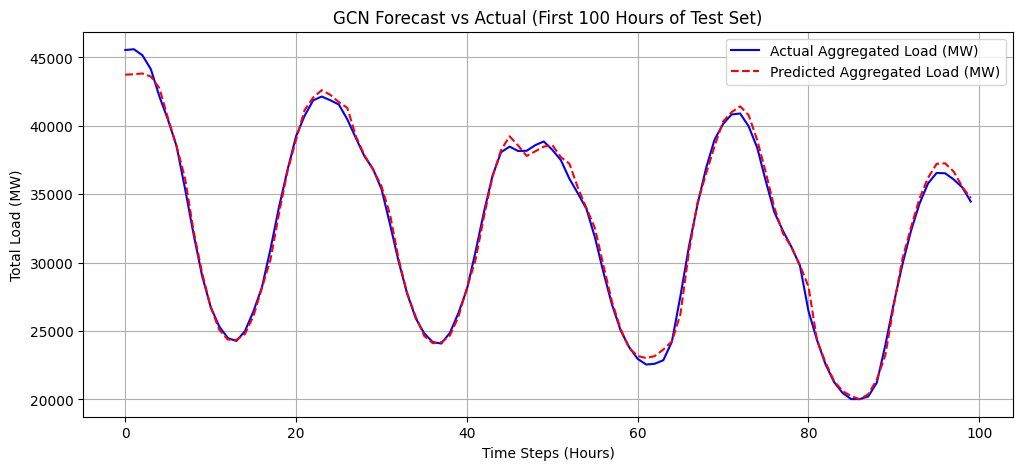

In [9]:
print("--- Final Model Evaluation (Aggregated Florida Load) ---")
print(f"MAPE: {mape:.2f}%")
print(f"RMSE: {rmse:.2f} MW")

# Optional: Plot a small window of predictions vs actuals
plt.figure(figsize=(12, 5))
plt.plot(Y_true[:100], label='Actual Aggregated Load (MW)', color='blue')
plt.plot(Y_pred[:100], label='Predicted Aggregated Load (MW)', color='red', linestyle='--')
plt.title('GCN Forecast vs Actual (First 100 Hours of Test Set)')
plt.xlabel('Time Steps (Hours)')
plt.ylabel('Total Load (MW)')
plt.legend()
plt.grid(True)
plt.show()

--- Final Model Evaluation (Aggregated Florida Load) ---
MAPE: 1.05%
RMSE: 460.64 MW
